<b>Задание</b>
1. Познакомьтесь с данными.
2. Осуществите предобработку данных для дальнейшего исследования, обработайте аномалии.
3. Добавьте информацию из датасета region.csv.
4. Восстановите пропуски в столбце kitchen_area. 
5. Исследуйте рынок недвижимости в РФ за представленный период. Величина исследования - цена за м2. Обработайте аномалии.
6. Когда выгодно покупать/продавать объект недвижимости? 
7. Определите от каких признаков зависит стоимость объекта недвижимости. Найдите скрытые закономерности.
8. Выдвинете и проверьте собственную гипотезу статистическими методами.
9. Создайте модель прогноза цены объекта недвижимости.

In [360]:
import pandas as pd
realty = pd.read_csv('realty_18_21.csv', sep=',')

In [361]:
# для ознакомления со структурой данных загрузим файл и выведем первые пять строк.
realty.head(5)

,price,date,region,building_type,level,levels,rooms,area,kitchen_area,object_type
0,6050000,2018-02-19,2661,1,8,10,3,82.6,10.8,1
1,8650000,2018-02-27,81,3,5,24,2,69.1,12.0,1
2,4000000,2018-02-28,2871,1,5,9,3,66.0,10.0,1
3,1850000,2018-03-01,2843,4,12,16,2,38.0,5.0,11
4,5450000,2018-03-01,81,3,13,14,2,60.0,10.0,1


In [362]:
realty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   price          int64  
 1   date           object 
 2   region         int64  
 3   building_type  int64  
 4   level          int64  
 5   levels         int64  
 6   rooms          int64  
 7   area           float64
 8   kitchen_area   float64
 9   object_type    int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 417.9+ MB


**<span style="color:#FF0000">price</span>** следует перевести из целочисленного типа в вещественный, поскольку цена представляет собой непрерывную величину, строковый формат **<span style="color:#FF0000">date</span>**  требует преобразования в datetime64, а **<span style="color:#FF0000">building_type</span>** и **<span style="color:#FF0000">object_type</span>**, закодированные как целочисленные, должны быть приведены к типу category для корректной обработки

Названия столбцов **корректны** и соответствуют принятым правилам оформления. Однако скорректируем порядок столбцов в соответствии с предоставленным описанием.

In [363]:
realty = realty[['date', 'region', 'building_type', 'object_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'price']]

In [364]:
# проверка
realty.head(1)

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000


Начнем с преобразования типов данных, поскольку тип данных определяет природу каждого столбца. Это необходимое условие для корректной последующей обработки пропусков.

In [365]:
realty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   date           object 
 1   region         int64  
 2   building_type  int64  
 3   object_type    int64  
 4   level          int64  
 5   levels         int64  
 6   rooms          int64  
 7   area           float64
 8   kitchen_area   float64
 9   price          int64  
dtypes: float64(2), int64(7), object(1)
memory usage: 417.9+ MB


In [366]:
realty['date'] = pd.to_datetime(realty['date'], format='%Y-%m-%d')

In [367]:
realty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 10 columns):
 #   Column         Dtype         
---  ------         -----         
 0   date           datetime64[ns]
 1   region         int64         
 2   building_type  int64         
 3   object_type    int64         
 4   level          int64         
 5   levels         int64         
 6   rooms          int64         
 7   area           float64       
 8   kitchen_area   float64       
 9   price          int64         
dtypes: datetime64[ns](1), float64(2), int64(7)
memory usage: 417.9 MB


Столбцы **building_type** и **object_type** являются категориальными переменными, поэтому преобразуем их в тип category

In [368]:
realty['building_type'] = realty['building_type'].astype('category')
realty['object_type'] = realty['object_type'].astype('category')
realty['price'] = realty['price'].astype('float')    #цена - непрервная величина, требует преобразования в соответствующий тип данных

In [369]:
realty['building_type'].unique()    # Pandas создал логический порядок категорий

[1, 3, 4, 2, 5, 0]
Categories (6, int64): [0, 1, 2, 3, 4, 5]

In [370]:
realty['object_type'].unique()

[1, 11]
Categories (2, int64): [1, 11]

In [371]:
realty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5477006 entries, 0 to 5477005
Data columns (total 10 columns):
 #   Column         Dtype         
---  ------         -----         
 0   date           datetime64[ns]
 1   region         int64         
 2   building_type  category      
 3   object_type    category      
 4   level          int64         
 5   levels         int64         
 6   rooms          int64         
 7   area           float64       
 8   kitchen_area   float64       
 9   price          float64       
dtypes: category(2), datetime64[ns](1), float64(3), int64(4)
memory usage: 344.7 MB


**Обработка пропусков (кроме <span style="color:#800020">kitchen_area</span>)**

In [372]:
realty.isna().sum()

date                  0
region                0
building_type         0
object_type           0
level                 0
levels                0
rooms                 0
area                  0
kitchen_area     253711
price                 0
dtype: int64

Пропуски содержатся только в столбце kitchen_area, их мы пока не трогаем, переходим к следующему этапу

**Обработка дубликатов**

In [373]:
#явные дубликаты
duplicates = realty.duplicated().sum()
duplicates

np.int64(235655)

In [374]:
volume_realty = realty.shape
volume_realty

(5477006, 10)

In [375]:
# доля явных дубликатов
duplicates/realty.shape[0]

np.float64(0.04302624463073438)

Доля явных дубликатов 0,043 или 4,3%: достаточно значительная, но вполне управляемая.

Метод drop_duplicates() оперируют только явными дубликатами, поэтому можем смело удалять все 4% повторяющихся значений

In [376]:
realty.loc[realty.duplicated(keep=False)].head(5)

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price
402,2018-09-08,9654,1,11,5,10,1,41.36,10.88,1300000.0
403,2018-09-08,9654,1,1,9,10,1,58.03,17.00,1750000.0
420,2018-09-08,9654,1,1,3,10,1,33.58,5.00,1050000.0
421,2018-09-08,9654,1,1,1,10,1,58.03,17.00,1700000.0
433,2018-09-08,9654,1,11,4,10,1,33.58,5.00,940240.0


In [377]:
realty = realty.drop_duplicates().reset_index(drop=True)

In [378]:
volume_realty[0] - realty.shape[0]    #отлично, удалились только явные дубликаты

235655

In [379]:
realty.loc[realty[['region', 'building_type', 'object_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'price']].duplicated(keep=False)]

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price
5,2018-03-02,81,1,1,4,5,1,32.0,6.0,3300000.0
20,2018-03-17,3,1,1,5,9,2,45.0,6.0,8000000.0
23,2018-03-20,2871,2,11,6,25,1,44.0,20.0,2697200.0
27,2018-03-30,81,3,1,2,5,3,75.0,9.0,5300000.0
30,2018-04-04,3230,1,1,5,10,3,65.0,12.0,3500000.0
...,...,...,...,...,...,...,...,...,...,...
5241296,2021-05-01,2871,1,1,3,17,3,88.0,12.0,6700000.0
5241303,2021-05-01,9654,1,1,5,9,2,51.0,9.0,3250000.0
5241317,2021-05-01,5789,3,1,5,5,3,87.5,10.6,5500000.0
5241339,2021-05-01,3,1,1,1,12,-1,17.0,3.0,3750000.0


Обнаружены полные технические дубликаты объектов недвижимости: записи идентичны по всем параметрам (регион, тип объекта, этаж, площадь кухни и тд, а самое главное цена), за исключением столбца с датой публикации.

Это почти наверняка один и тот же объект недвижимости, который многократно выгружался или обновлялся в базе данных, что и привело к разным датам.

In [380]:
realty[['region', 'building_type', 'object_type', 'level', 'levels', 'rooms', 'area', 'kitchen_area', 'price']].duplicated().sum()/len(realty)

np.float64(0.19053389097581902)

Получилось около 1 миллиона строк, или порядка 19% данных! Такой высокий процент подтверждает, что это систематическая проблема многократного обновления данных одного и того же объекта.

Последняя дата отражает текущее состояние объявления на рынке.

Считаем, что необходимо оставить наборт с тех. ддубликатами, который включает полную историю по объектам недвижимости. Этот позволит проанализировать рыночную динамику: например, определить, в какие периоды выгоднее совершать сделки.

Обработка **<span style="color:#E74C3C">логических аномалий</span>**

Мы должны проверить, что ключевые числовые признаки (которые не могут быть <= 0) содержат **положительные** значения.

In [381]:
realty[realty['area'] <= 0]

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price


In [382]:
realty[realty['kitchen_area'] <= 0]    #с общей площадью, площадью кухни в этом плане все хорошо

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price


In [383]:
realty[realty['price'] <= 0]    #неположительная цена, чего в реальности не бывает

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price
43244,2018-09-14,5520,1,11,13,22,1,38.92,NaN,-1.633967e+09
43245,2018-09-14,5520,1,11,14,22,1,38.92,17.26,-1.633967e+09
171456,2018-10-01,6817,3,1,5,10,3,104.00,15.00,0.000000e+00
190680,2018-10-04,9654,2,11,5,25,2,57.27,9.31,-4.292423e+08
198061,2018-10-06,9654,3,1,4,5,2,45.00,6.00,-1.744967e+09
...,...,...,...,...,...,...,...,...,...,...
5147253,2021-04-23,2604,3,11,2,4,1,41.08,9.31,-2.041757e+09
5147655,2021-04-23,81,1,1,4,5,2,56.00,9.00,-1.794967e+09
5163220,2021-04-26,2843,3,11,3,3,1,45.00,17.00,-1.494967e+09
5184182,2021-04-27,3991,3,1,14,19,1,30.00,8.00,-2.094967e+09


In [384]:
realty[realty['price'] <= 0]['price'].count()    #таких 334 объекта, это абсолютная критическая аномалия, которую невозможно обработать, 
#удаляем эти строки из рассмотрения

np.int64(334)

Нулевая, минимальная цена объекта - **маркетинговый приём**, направленный на повышение позиции в посике, либо просто артефакт (ошибка при сборе данных)

In [385]:
realty = realty[realty['price'] > 0].copy()    #новенький сет без ценовых аномалий

In [386]:
anomalies_level = realty[realty['level'] > realty['levels']]['level'].count()    #число аномалий, где этаж конкретного объекта ВЫШЕ общей этажности дома,
#угадать какой-же там этаж подразумевается практически невозможно
anomalies_level

np.int64(665)

In [387]:
#смотрим долю таких объектов
print(f"Доля аномалий с этажностью: {(anomalies_level / realty.shape[0]).round(5)}")

Доля аномалий с этажностью: 0.00013


Таких объектов порядка 0,013%, что крайне **несущественно**, можно смело удалять без какого-либо влияния на результаты анализа.

In [388]:
realty = realty[realty['level'] <= realty['levels']].copy()    #сетик без этажных аномалий

In [389]:
realty['rooms'].value_counts()
#-1 - это студия, что же скрывается за -2? 

rooms
 1     1965455
 2     1777431
 3     1054398
-1      267686
 4      149099
 5       22105
 6        2355
 7         788
 8         353
-2         343
 9         338
 10          1
Name: count, dtype: int64

In [390]:
#есть вероятность, что это ошибка ввода данных, автор имел ввиду 2 - двушку, посмотрим на описательную статистику
realty[realty['rooms'] == 2]['area'].describe()

count    1.777431e+06
mean     5.539511e+01
std      2.770563e+01
min      7.000000e-02
25%      4.600000e+01
50%      5.400000e+01
75%      6.200000e+01
max      7.625000e+03
Name: area, dtype: float64

In [391]:
#распределение данных для rooms = -2
realty[realty['rooms'] == -2]['area'].describe()

count     343.000000
mean      160.996210
std       194.428375
min         9.000000
25%         9.000000
50%        41.300000
75%       280.000000
max      1000.000000
Name: area, dtype: float64

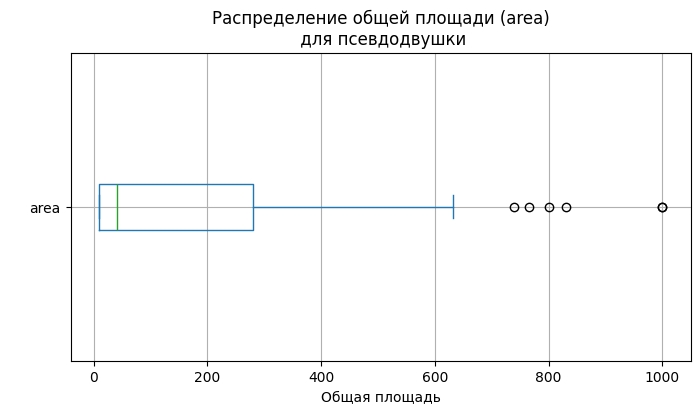

In [392]:
import matplotlib.pyplot as plt
import seaborn as sns
realty.query('rooms == -2')['area'].plot(kind='box', figsize=(8, 4), grid=True, vert=False, title='Распределение общей площади (area)\n для псевдодвушки', 
                                xlabel='Общая площадь',
                                ylabel=' ')
plt.show()

Очень странная описательная статистика, медиана в пределах нормы (близка к типичной двушке), но минимальная площадь 9 кв м, что слишком мало для двухкомнатной квартиры. Среднее подскочило за счет выбросов, разброс очень большой, вероятно там собраны объекты с разным метражом (двушки (возможно) + аномалии). 

In [393]:
import numpy as np
q75_r = np.percentile(realty.query('rooms == -2')['area'], 75)    #для идентификации выбросов используем сначала iqr
q25_r = np.percentile(realty.query('rooms == -2')['area'], 25)
iqr = q75_r - q25_r
ejection_h_rooms = q75_r + 1.5 * iqr    #верхняя граница выбросов
ejection_l_rooms = q25_r - 1.5 * iqr    #нижняя граница выбросов
print(f"Верхняя граница выбросов: {ejection_h_rooms}, нижняя граница выбросов {ejection_l_rooms}")

Верхняя граница выбросов: 686.5, нижняя граница выбросов -397.5


In [394]:
#количество выбросов
n_ejection_r = realty[(realty['rooms'] == -2) & (realty['area'] >= ejection_h_rooms)]['area'].count()
print(f"Число выбросов: {n_ejection_r}")

Число выбросов: 6


In [395]:
area_no_ej = realty[(realty['rooms'] == -2) & (realty['area'] < ejection_h_rooms)]['area']

In [396]:
area_no_ej.describe()   #результаты не радуют, все дальше от типичных двушек (разброс так же велик, медиана больше характерна для однушек), удаляем

count    337.000000
mean     148.623145
std      171.757091
min        9.000000
25%        9.000000
50%       39.000000
75%      280.000000
max      631.200000
Name: area, dtype: float64

In [397]:
realty = realty[realty['rooms'] != -2].copy()

Далее необходимо проверить, чтобы площадь кухни не была больше (или не равнялась) общей площади

In [398]:
anomalies_area = realty[realty['kitchen_area'] >= realty['area']]['kitchen_area'].count()
anomalies_area

np.int64(4064)

In [399]:
print(f"Доля аномалий с площадью кухни: {(anomalies_area / realty.shape[0]).round(4)}")

Доля аномалий с площадью кухни: 0.0008


Аномалии, где площадь кухни больше или равна общей площади, следует удалить, потому что такие значения являются логически невозможными, которые **<span style="color:#FF0000">нельзя</span>** достоверно восстановить без дополнительной информации.

In [400]:
realty = realty[(realty['kitchen_area'] < realty['area']) | (realty['kitchen_area'].isna())].copy()

In [401]:
realty.shape

(5235945, 10)

Добавьте информацию из датасета **<span style="color:#FF0000">region.csv</span>**

In [402]:
regions = pd.read_csv('region.csv', sep=',')
regions.head(1)

,code,reg_name
0,2661,Санкт-Петербург


In [403]:
regions.info()    # код региона - формат object, потому переведем код региона в основном фрэйме в строчный формат

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   code      83 non-null     object
 1   reg_name  83 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB


In [404]:
realty['region'] = realty['region'].astype(str)

In [405]:
realty = realty.merge(regions, left_on='region', right_on='code', how='left')    #соединяем

In [406]:
realty.isna().sum()

date                  0
region                0
building_type         0
object_type           0
level                 0
levels                0
rooms                 0
area                  0
kitchen_area     252613
price                 0
code               6875
reg_name           6875
dtype: int64

In [407]:
realty[realty['reg_name'].isna()]['region'].unique()    #не восстановились значения регионов с номерами ниже

array(['7873', '6937'], dtype=object)

In [408]:
# обратившись к интернет-источникам, выяснили:
# 7873: 'Республика Крым', 6937: 'Республика Крым'
realty.loc[realty['region'] == '7873', 'code'] = realty.loc[realty['region'] == '7873', 'code'].fillna('7873')
realty.loc[realty['region'] == '6937', 'code'] = realty.loc[realty['region'] == '6937', 'code'].fillna('6937')

In [409]:
realty.isna().sum()    #ура, один столбец заполнили

date                  0
region                0
building_type         0
object_type           0
level                 0
levels                0
rooms                 0
area                  0
kitchen_area     252613
price                 0
code                  0
reg_name           6875
dtype: int64

In [410]:
region_name_no = {'7873': 'Республика Крым', '6937': 'Республика Крым'}
realty['reg_name'] = realty['reg_name'].fillna(realty['code'].map(region_name_no))

In [411]:
realty.isna().sum()    #регионы все восстановили

date                  0
region                0
building_type         0
object_type           0
level                 0
levels                0
rooms                 0
area                  0
kitchen_area     252613
price                 0
code                  0
reg_name              0
dtype: int64

In [412]:
realty.head(1)

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,code,reg_name
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,2661,Санкт-Петербург


In [413]:
realty = realty.drop('code', axis=1)    #удалим столбец с code, он польностью дублирует region

In [414]:
realty.head(1)

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург


Восстановим пропуски в столбце **<span style="color:#FF0000">kitchen_area</span>**

In [415]:
print(f"Доля пропусков в столбце kitchen_area: {(realty['kitchen_area'].isna().sum() / len(realty['kitchen_area'])).round(3)}")

Доля пропусков в столбце kitchen_area: 0.048


Доля пропусков вполне управляема для такого объема данных, будем решать как ее обрабатывать

Попробуем заполнить пропуски в столбце kitchen_area с помощью множественной линейной регрессии, предсказывая площадь кухни на основе общей площади и количества комнат.

In [416]:
linreg = realty.copy()    #просто создали копию нашего сетика

In [417]:
linreg.isna().sum()

date                  0
region                0
building_type         0
object_type           0
level                 0
levels                0
rooms                 0
area                  0
kitchen_area     252613
price                 0
reg_name              0
dtype: int64

In [418]:
all_y = linreg[~linreg['kitchen_area'].isna()]['kitchen_area'].copy()    #для обучения и тестирования модели будем брать только те значения,
#где в kitchen_area нет пропусков
all_x = linreg[~linreg['kitchen_area'].isna()][['rooms', 'area']].copy()

In [419]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(all_x, all_y, test_size=0.2, random_state=13)

In [420]:
#используем стандартизатор для обучающей выборки
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_st = scaler.fit_transform(x_train)
x_train_st

array([[ 0.23709095,  0.54490683],
       [ 1.17409622,  0.16311661],
       [ 1.17409622,  1.15458734],
       ...,
       [ 0.23709095, -0.30450242],
       [ 1.17409622,  0.80831249],
       [-0.69991432, -0.47320042]], shape=(3986665, 2))

In [421]:
#используем стандартизатор для тестовой выборки
x_test_st = scaler.transform(x_test)
x_test_st

array([[-0.69991432, -0.14941864],
       [-2.57392487, -0.44064467],
       [ 0.23709095,  0.05065127],
       ...,
       [ 1.17409622,  0.71064522],
       [-0.69991432, -0.47320042],
       [-0.69991432, -0.64781766]], shape=(996667, 2))

In [422]:
from sklearn.linear_model import Ridge
model = Ridge()    #регуляризация, избавляемся от мультикорреляции

# обучим модель
model.fit(x_train_st, y_train)

# применим обученную модель к данным, в которых были пропуски в столбце kitchen_area
y_pred = model.predict(x_test_st)

print(model.coef_, model.intercept_)    #свободный член и коэф. при объясняющих переменных

[0.22891862 2.52354261] 10.636981612450507


In [423]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
r2    #провальная идея, плохая объясняющая составляющая

0.21074213892969662

Попробуем заполнить пропуски с помощью **медианных долей** (доля площади кухни от общей), рассчитанных по ключевым признакам: количество комнат, регион и тип дома.

In [424]:
grouping_by_key_features = ['building_type', 'rooms', 'reg_name']    #выберем ключевые признаки для фильтрации

In [425]:
consider = realty[~realty['kitchen_area'].isna()].copy()
consider['share_kitchen_area_typical'] = (consider['kitchen_area'] / consider['area']).round(3)    #доля кухни в общей площади

In [426]:
consider.head(1)    #фильтрация в столбце kitchen_area (выбраны все значения БЕЗ NAN)

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.131


In [427]:
median_share = consider.groupby(grouping_by_key_features)['share_kitchen_area_typical'].median().reset_index()
median_share

C:\Users\zabav\AppData\Local\Temp\ipykernel_24440\2271712286.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_share = consider.groupby(grouping_by_key_features)['share_kitchen_area_typical'].median().reset_index()


,building_type,rooms,reg_name,share_kitchen_area_typical
0,0,-1,Алтайский край,0.1635
1,0,-1,Амурская область,NaN
2,0,-1,Архангельская область,0.2670
3,0,-1,Астраханская область,NaN
4,0,-1,Белгородская область,0.2980
...,...,...,...,...
5473,5,10,Челябинская область,NaN
5474,5,10,Чеченская Республика,NaN
5475,5,10,Чувашская Республика,NaN
5476,5,10,Ямало-Ненецкий автономный округ,NaN


In [428]:
median_share = median_share[~median_share['share_kitchen_area_typical'].isna()]    #убираем пустые значения, они нам не помогут

In [429]:
median_share.head(1)

,building_type,rooms,reg_name,share_kitchen_area_typical
0,0,-1,Алтайский край,0.1635


In [430]:
realty = realty.merge(
    median_share[['building_type', 'rooms', 'reg_name', 'share_kitchen_area_typical']],
    on=['building_type', 'rooms', 'reg_name'],
    how='left')
# присоединяем типичную долю площади кухни от общей для строк с пропусками в kitchen_area

In [431]:
realty.isna().sum()

date                               0
region                             0
building_type                      0
object_type                        0
level                              0
levels                             0
rooms                              0
area                               0
kitchen_area                  252613
price                              0
reg_name                           0
share_kitchen_area_typical        21
dtype: int64

In [432]:
realty.shape

(5235945, 12)

In [433]:
index_ka = realty[realty['kitchen_area'].isna()].index    #восстанавливаем пропуски
realty.loc[index_ka, 'kitchen_area'] = realty.loc[index_ka, 'share_kitchen_area_typical'] * realty.loc[index_ka, 'area']

In [434]:
realty.isna().sum()

date                           0
region                         0
building_type                  0
object_type                    0
level                          0
levels                         0
rooms                          0
area                           0
kitchen_area                  21
price                          0
reg_name                       0
share_kitchen_area_typical    21
dtype: int64

In [435]:
realty[realty['kitchen_area'].isna()]['rooms'].value_counts()

rooms
 4    5
 5    5
 9    4
 7    3
 3    2
 8    1
-1    1
Name: count, dtype: int64

In [436]:
realty[realty['kitchen_area'].isna()]['reg_name'].unique()

array(['Удмуртская Республика', 'Саратовская область',
       'Ставропольский край', 'Санкт-Петербург', 'Пермский край',
       'Омская область', 'Курганская область', 'Оренбургская область',
       'Свердловская область', 'Республика Бурятия', 'Мурманская область',
       'Республика Адыгея', 'Магаданская область', 'Забайкальский край',
       'Кабардино-Балкарская Республика', 'Ярославская область',
       'Республика Башкортостан', 'Калужская область'], dtype=object)

In [437]:
shape = (realty['kitchen_area'].isna().sum() / len(realty)).round(4)
shape

np.float64(0.0)

После заполнения пропусков остался 21 объект с неустранимыми пропусками. Удалим эти строки. Такой подход надёжнее, чем использование **непроверенных методов** заполнения.

In [438]:
realty = realty[~realty['kitchen_area'].isna()]

In [439]:
realty.isna().sum()

date                          0
region                        0
building_type                 0
object_type                   0
level                         0
levels                        0
rooms                         0
area                          0
kitchen_area                  0
price                         0
reg_name                      0
share_kitchen_area_typical    0
dtype: int64

In [440]:
realty.head(1)

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127


**Обработаем выбросы**

In [441]:
realty['area'].describe()    #посмотрим на распределение данных

count    5.235924e+06
mean     5.397981e+01
std      3.371275e+01
min      2.200000e-01
25%      3.800000e+01
50%      4.802000e+01
75%      6.320000e+01
max      7.856000e+03
Name: area, dtype: float64

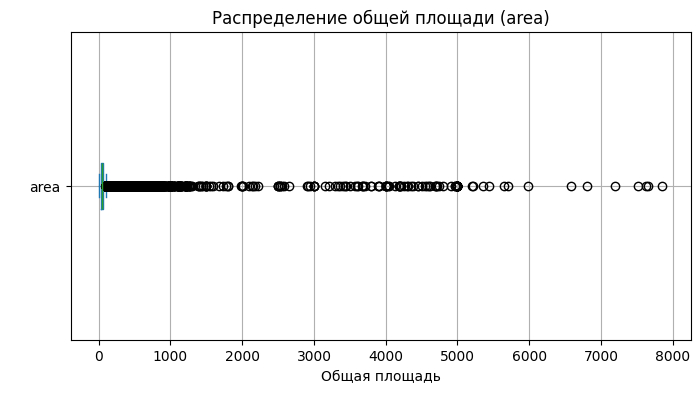

In [442]:
realty['area'].plot(kind='box', figsize=(8, 4), grid=True, vert=False, title='Распределение общей площади (area)', 
                                xlabel='Общая площадь',
                                ylabel=' ')
plt.show()

Наблюдается **огромное** число экстремальных значений

In [443]:
q75_area = np.percentile(realty['area'], 75)    #для идентификации выбросов используем сначала iqr
q25_area = np.percentile(realty['area'], 25)
iqr_area = q75_area - q25_area
ejection_h_area = q75_area + 1.5 * iqr_area    #верхняя граница выбросов
ejection_l_area = q25_area - 1.5 * iqr_area    #нижняя граница выбросов
print(f"Верхняя граница выбросов: {ejection_h_area}, нижняя граница выбросов {ejection_l_area}")

Верхняя граница выбросов: 101.0, нижняя граница выбросов 0.19999999999999574


In [444]:
#количество выбросов
n_ejection_area = realty[(realty['area'] > ejection_h_area) | (realty['area'] < ejection_l_area)]['area'].count()
print(f"Число выбросов: {n_ejection_area}")

Число выбросов: 185719


In [445]:
ejection_perc_area = ((n_ejection_area / len(realty['area'])) * 100).round(3)
print(f"% выбросов: {ejection_perc_area}")

% выбросов: 3.547


Следует рассмотреть 99-й квантиль в качестве верхней границы для очистки данных, поскольку он является менее агрессивным подходом, чем метод IQR, и помогает сохранить больший объем данных.

In [446]:
lower_area = realty['area'].quantile(0.01)    #нижняя граница
upper_area = realty['area'].quantile(0.99)    #верхняя граница
#количество выбросов
n_area_ej = realty[(realty['area'] > upper_area) | (realty['area'] < lower_area)]['area'].count()
n_area_ej

np.int64(102828)

In [447]:
n_perc_area = ((n_area_ej / len(realty['area'])) * 100).round(3)
print(f"% выбросов: {n_perc_area}")    #объем выбросов сократился, метод фильтрации удалил только самые экстремальные объекты

% выбросов: 1.964


Это все равно достаточно большой объем данных, чтобы слепо его удалять, так как могут существовать реальные элитные объекты или бюджетное жильё.

Посмотрим на цену.

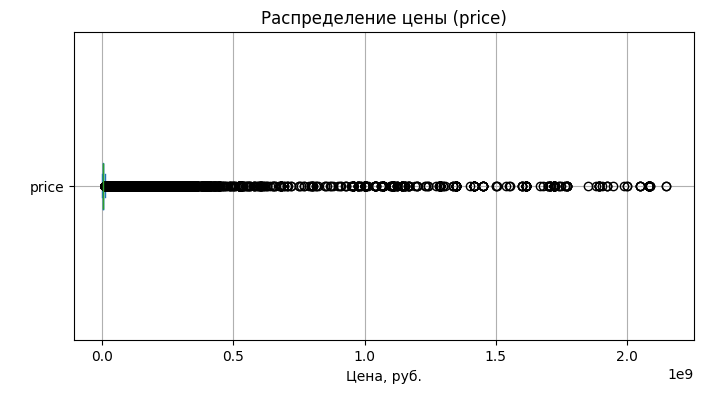

In [448]:
realty['price'].plot(kind='box', figsize=(8, 4), grid=True, vert=False, title='Распределение цены (price)', 
                                xlabel='Цена, руб.',
                                ylabel=' ')
plt.show()

In [449]:
# опять же наблюдаем большое количество выбросов, минимизируем потерю данных, воспользовавшись 99 квантилем для фильтрации выбросов
lower_pr = realty['price'].quantile(0.01)    #нижняя граница
upper_pr = realty['price'].quantile(0.99)    #верхняя граница
#количество выбросов
n_em_price = realty[(realty['price'] > upper_pr) | (realty['price'] < lower_pr)]['area'].count()
n_em_price

np.int64(103244)

In [450]:
n_perc = ((n_em_price / len(realty['price'])) * 100).round(3)
print(f"% выбросов: {n_perc}") #процент выбросов не зашкаливающий, можем убрать критические значения

% выбросов: 1.972


Пока не будем удалять выбросы ни в абсолютной цене, ни в общей площади, потому что правильнее анализировать их совместно через цену за квадратный метр (позволит отделить реально дорогие или большие объекты от ошибок в данных).

Допускается проектировать кухни или кухни-ниши площадью не менее 3 кв. м, то есть значения менее 3 квадратных метров невозможны и являются ошибками в данных. Меньше 3 кв. м невозможно, так как это не позволяет разместить даже минимальный набор кухонного оборудования с учётом нормативных требований к габаритам и проходам.

In [451]:
realty[realty['kitchen_area'] < 3]['kitchen_area'].count()

np.int64(63892)

In [452]:
realty[realty['kitchen_area'] < 3].head(2)

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical
314,2018-09-08,2843,2,1,7,9,1,31.3,2.0,1350000.0,Краснодарский край,0.278
405,2018-09-08,9654,1,11,7,10,1,33.0,1.0,890000.0,Новосибирская область,0.262


In [453]:
realty = realty[realty['kitchen_area'] >= 3].copy()

Проанализировали самый жёсткий критерий (площадь кухни менее 3 кв. м). Оставшиеся значения как абсолютного метража, так и доли кухни от общей площади в целом могут соответствовать реальным объектам недвижимости.

Все хорошо, предобработка данных завершена

**Исследование рынка недвижимости в РФ за представленный период. Величина исследования - цена за м2. Обработка аномалий.**

In [454]:
realty # выводим предобработанные данные

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150
...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173


In [455]:
# перед началом исследования рынка недвижимости РФ необходимо рассчитать цену за м2, поэтому мы добавляем столбец с ценой за квадратный метр.
realty['price_m2'] = realty['price'] / realty['area']
realty

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000


**Далее перейдем к временным аномалиям.**

In [456]:
realty['date'].max() 
# проверяя дату последнего объявнения, мы убеждаемся, что датасет не содержит информации 
# "из будущего", все данные достоверны

Timestamp('2021-05-01 00:00:00')

In [457]:
realty['date'].min() 
# здесь мы не ставим ограничений, так как столбец с датой отражает динамику по годам, а не "свежесть" объявлений
# квартира может быть продана в январе 2018 года даже несмотря на то, что само 
# объявление могло быть опубликовано в том же месяце. Каждое объявление, 
# которое после продажи удаляется или архивируется, отражается в общей динамике и датасете соответсвенно. 

Timestamp('2018-02-19 00:00:00')

Обработав явные аномалии, мы можем перейти к удалению *статистических аномалий*. 

In [458]:
qua75 = np.percentile(realty['price_m2'], 75) # третий квартиль
qua25 = np.percentile(realty['price_m2'], 25) # первый квартиль
iqr = qua75-qua25 # межквартильный размах 
high = qua75 + 1.5*iqr # верхняя граница выбросов
lower = qua25 - 1.5*iqr # нижняя граница выбросов

In [459]:
n_ejection = realty['price_m2'][(realty['price_m2'] > high) | (realty['price_m2'] < lower)].count()
print('Число выбросов:', n_ejection) # определяем число выбросов

Число выбросов: 386703


In [460]:
eject_perc = ((n_ejection / len(realty['price_m2'])) * 100).round(3)
print(f"% выбросов: {eject_perc}")

% выбросов: 7.477


In [461]:
low = realty['price_m2'].quantile(0.01)    #нижняя граница
upp = realty['price_m2'].quantile(0.99)    #верхняя граница
#количество выбросов
n_eject = realty[(realty['price_m2'] > upp) | (realty['price_m2'] < low)]['price_m2'].count()
print(f"Количество выбросов: {n_eject}")

Количество выбросов: 102784


In [462]:
low, upp

(np.float64(17818.18181818182), np.float64(300000.0))

In [463]:
eject_perc2 = ((n_eject / len(realty['price_m2'])) * 100).round(3)
print(f"% выбросов: {eject_perc2}")

% выбросов: 1.987


При использовании **IQR-метода** процент выбросов получился равным 7.48%. 
Таким образом, эти 7.48% данных - не аномалии, а особенности рынка. Удаление такого массива информации является неразумным решением. Скорее всего, IQR-метод удаляет очень много данных из верхнего хвоста распределения: информация об "элитном" жилье вряд ли учитывается, мы теряем целый сегмент рынка. В нашем случае лучшим решением для очистки данных будет использование перцентилей. 

In [464]:
good_data_wait_time = realty[(realty['price_m2'] <= upp) & (realty['price_m2'] >= low)]
good_data_wait_time = good_data_wait_time.reset_index(drop=True)
good_data_wait_time # создаем новый датасет без учета выбросов

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5069243,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000
5069244,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000
5069245,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046
5069246,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000


Очистив данные, мы приступим к более подробному **исследованию рынка недвижимости РФ** за 2018-2021 гг. (величина исследования - цена за м2).

In [465]:
realty['year'] = pd.DatetimeIndex(realty['date']).year

In [466]:
realty

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058,2018
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250,2018
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606,2018
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526,2018
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000,2021
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000,2021
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046,2021
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000,2021


Для начала рассмотрим медианные цены за период 2018-2021 гг. и визуализируем полученные результаты.

In [561]:
realty1 = realty.pivot_table(
    index = 'year',
    aggfunc = {'price_m2': 'mean'})
realty1 = realty1.reset_index() 
realty1.columns = ['year', 'mean_price_m2']
realty1

,year,mean_price_m2
0,2018,71716.209864
1,2019,75904.422079
2,2020,86202.109546
3,2021,106344.299955


<Axes: title={'center': 'Отчет о динамике медианной цены за м2 в период с 2018 г. по 2021 г.'}, xlabel='Год и месяц', ylabel='Выручка'>

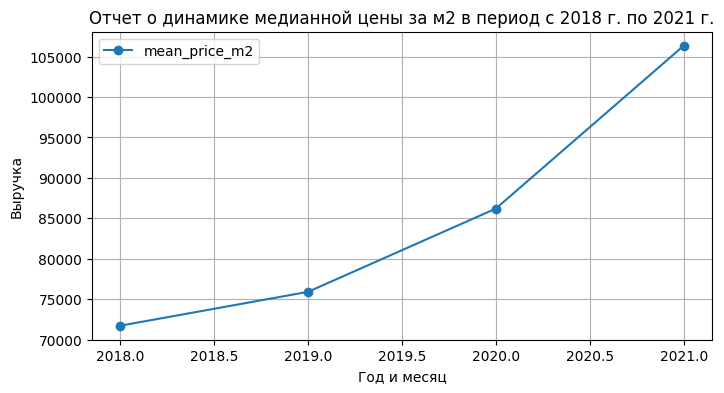

In [564]:
realty1.plot(x = 'year', 
                y = 'mean_price_m2', 
                title='Отчет о динамике медианной цены за м2 в период с 2018 г. по 2021 г.', 
                legend='False',
                xlabel = 'Год и месяц', 
                ylabel='Выручка', 
                style ='o-', 
                grid=True, 
                figsize=(8, 4))
# построение линейного графика, отражающего динамику медианной цены за м2 в период с 2018 г. по 2021 г.

Таким образом, цена на недвижимость в РФ за 2018-2021 годы резко возросла на (106344.30 - 71716.21)/ 71716.21 * 100 = 48.28%. **За 4 года типичная квартира в РФ подорожала почти на половину**.

In [469]:
realty['month'] = pd.DatetimeIndex(realty['date']).month

In [470]:
realty['period'] = realty['year'].astype(str) + '-' + realty['month'].astype(str)

In [471]:
realty 

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year,month,period
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058,2018,2,2018-2
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250,2018,2,2018-2
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606,2018,2,2018-2
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526,2018,3,2018-3
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333,2018,3,2018-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000,2021,5,2021-5
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000,2021,5,2021-5
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046,2021,5,2021-5
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000,2021,5,2021-5


Посмотрим, как **менялись цены от месяца к месяцу** на протяжении 4 лет.

In [472]:
realty2 = realty.pivot_table(
    index = 'period',
    aggfunc = {'price_m2': 'mean'})
realty2 = realty2.reset_index() 
realty2.columns = ['year', 'median_price_m2']
realty2

,year,median_price_m2
0,2018-10,68000.565834
1,2018-11,71324.076678
2,2018-12,73820.739146
3,2018-2,86343.836638
4,2018-3,79668.590759
5,2018-4,82785.185007
6,2018-5,73509.057942
7,2018-6,69028.921978
8,2018-7,61932.539677
9,2018-8,73922.798460


In [473]:
# мы заметили, что месяцы в периодах идут не попорядку, что затрудняет анализ
# необходимо добавить к месяцу, состоящему из одного символа, например, "2" ноль, для того, чтобы
# он располагался выше месяца "12"
def zero (period):
    if len(period) == 6:  # если период состоит из 6 символов - "2018-3" - нужно добавить 0 перед 3
        return period.replace('-', '-0')
    else:  # в ином случае ("2018-10") ничего добавлять не нужно
        return period
realty['period'] = realty['period'].apply(zero)

In [554]:
realty2 = realty.pivot_table(
    index = 'period',
    aggfunc = {'price_m2': 'mean'})
realty2 = realty2.reset_index() 
realty2.columns = ['period', 'mean_price_m2']
realty2

,period,mean_price_m2
0,2018-02,86343.836638
1,2018-03,79668.590759
2,2018-04,82785.185007
3,2018-05,73509.057942
4,2018-06,69028.921978
5,2018-07,61932.539677
6,2018-08,73922.798460
7,2018-09,73617.192061
8,2018-10,68000.565834
9,2018-11,71324.076678


C:\Users\zabav\AppData\Local\Temp\ipykernel_24440\1382807866.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=12)


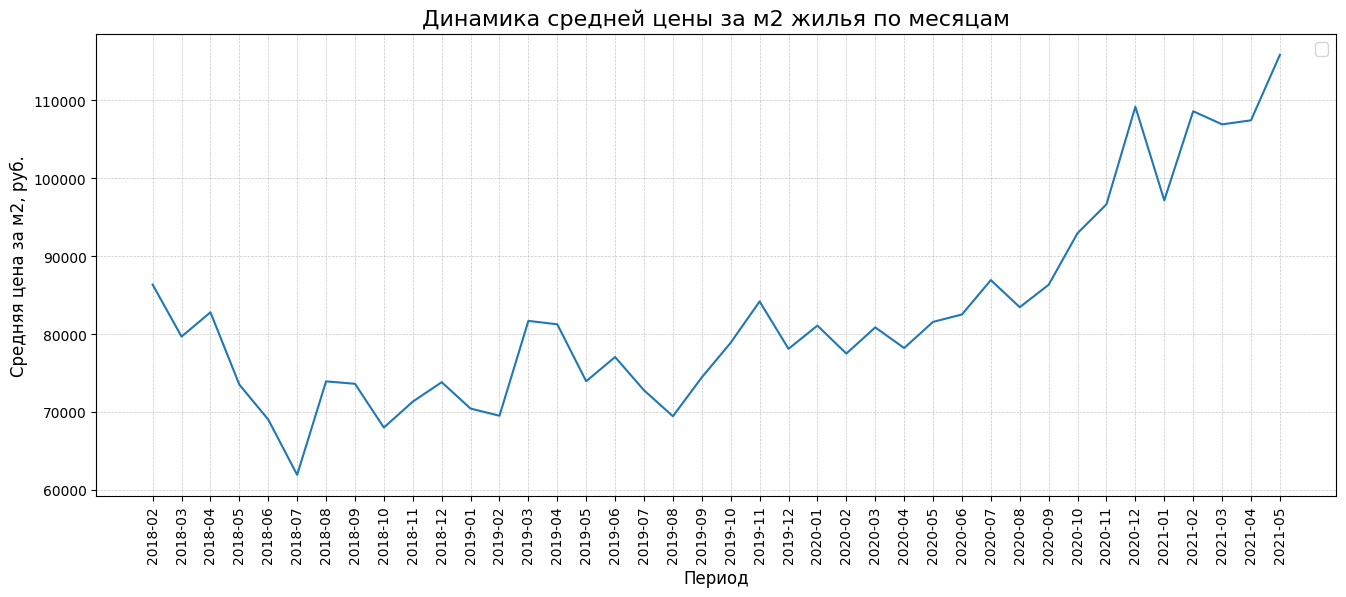

In [555]:
plt.figure(figsize=(16, 6))
sns.lineplot(data = realty2, x='period', y='mean_price_m2')
plt.title('Динамика средней цены за м2 жилья по месяцам', fontsize=16)
plt.xlabel('Период', fontsize=12)
plt.ylabel('Средняя цена за м2, руб.', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.show()
# визуализация

**Наблюдается устойчивый рост средней цены по годам**.

В **2018** году пик приходился на февраль:	86343.84 рублей за м2. Летом резкое падение до 61932.54 рублей за м2 и под конец года восстановление до 73820.74 рублей за м2.

**2019** год:
1. небольшое падение после новогодних праздников и каникул: цена опустилась до 69514.44 - 70433.73 руб за м2.;
2. резкий рост до 81683.85 в марте;
3. летом стабилизация в пределах 73000-77000 руб за м2;
4. осенью рост до 84180.19 за м2;
5. в декабре снова спад - 78098.95 руб за м2.

**2020** год: стабильная стоимость за м2 около 77000-83000 руб за м2 первые полгода. Во второй половине года - резкий рост до 86918.28 руб за м2, в декабре - 109154.24 руб за м2. Возможные причины: пандемия, дефицит кадров на стройплощадках -> повышали зарплаты для привлечения сотрудников, что увеличивало цены на жилье, запуск правительственной программы по льготной ипотеке, который привел к выкупу не самых ликвидных проектов и квартир).

**2021** год - пик на рынке.
Наблюдался рост: 97146.05 -> 106895.88 -> 115815.58 (максимум). Перегрев рынка, цены достигли исторических максимумов. Из-за предстоящего свертывания программы льготной ипотеки спрос на недвижимость сильно увеличился в 2021 году. Рост себестоимости строительства также повлиял на удорожание цены за м2. 

*Таким образом, начало года - это чаще всего спад стоимости за м2, весна - рост активности, осень и декабрь - пик сезона (кроме 2021 г.).*

Далее проведем **региональный анализ**.

Найдем топ-10 регионов с макс. и мин. средней ценой за м2 по каждому году.

In [477]:
realty_2018 = realty.query("year == 2018")

In [478]:
realty_18 = realty_2018.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_18.sort_values('price_m2', ascending=False).reset_index().head(10)
# топ-10 регионов с максимальной ценой за 2018 год

,reg_name,price_m2
0,Москва,177866.133144
1,Санкт-Петербург,114492.712408
2,Московская область,81965.087271
3,Республика Крым,74814.437190
4,Ненецкий автономный округ,70312.719389
5,Ленинградская область,66450.870272
6,Новосибирская область,64815.682399
7,Хабаровский край,63327.029748
8,Тюменская область,61695.335470
9,Республика Татарстан,61508.745370


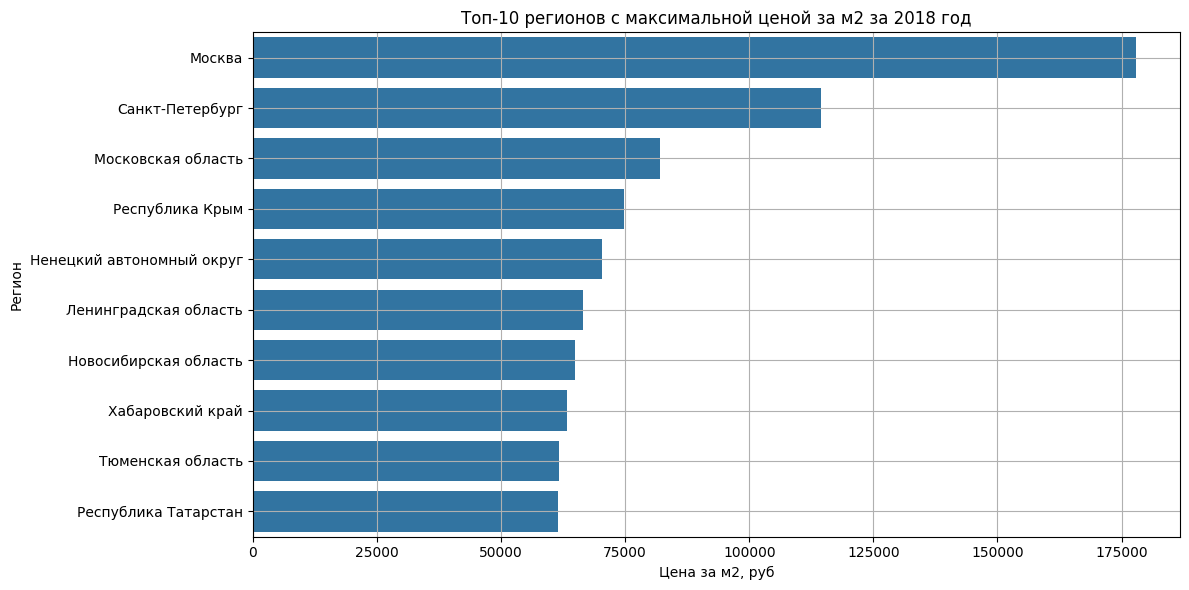

In [479]:
# визуализация отчета с топ-10 регионами с максимальной ценой за 2018 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_18.sort_values('price_m2', ascending=False).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с максимальной ценой за м2 за 2018 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

In [480]:
realty_18_min = realty_2018.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_18_min.sort_values('price_m2', ascending=True).reset_index().head(10)
# топ-10 регионов с минимальной ценой за 2018 год

,reg_name,price_m2
0,Республика Ингушетия,22905.905093
1,Курганская область,30684.592671
2,Республика Калмыкия,31759.421484
3,Сахалинская область,32791.773002
4,Псковская область,33834.004904
5,Ивановская область,34134.963993
6,Брянская область,34903.258420
7,Республика Марий Эл,36043.017587
8,Костромская область,36347.526121
9,Саратовская область,36402.944569


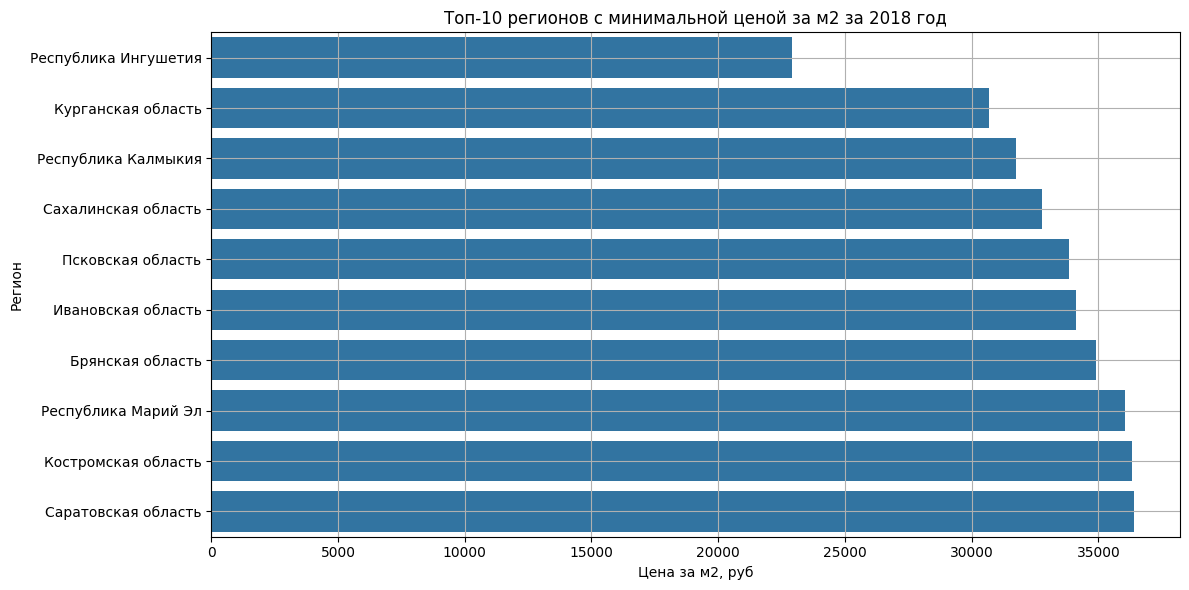

In [481]:
# визуализация отчета с топ-10 регионами с минимальной ценой за 2018 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_18_min.sort_values('price_m2', ascending=True).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с минимальной ценой за м2 за 2018 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

In [482]:
realty_2019 = realty.query("year == 2019")

In [483]:
realty_19 = realty_2019.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_19.sort_values('price_m2', ascending=False).reset_index().head(10)
# топ-10 регионов с максимальной ценой за 2019 год

,reg_name,price_m2
0,Москва,192843.356851
1,Сахалинская область,144444.444444
2,Санкт-Петербург,121131.385613
3,Республика Ингушетия,108264.180298
4,Республика Крым,92874.102471
5,Московская область,85345.896472
6,Ямало-Ненецкий автономный округ,78696.688620
7,Ханты-Мансийский автономный округ,75749.337895
8,Кировская область,73164.990038
9,Ленинградская область,71588.048474


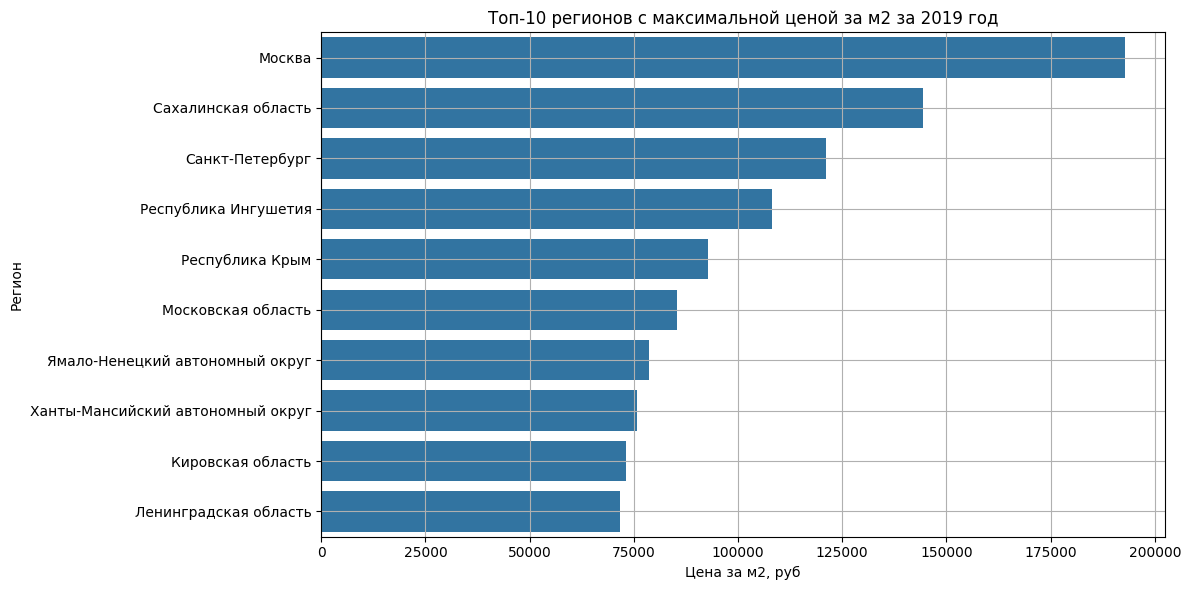

In [484]:
# визуализация отчета с топ-10 регионами с максимальной ценой за 2019 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_19.sort_values('price_m2', ascending=False).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с максимальной ценой за м2 за 2019 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

In [485]:
realty_19_min = realty_2019.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_19_min.sort_values('price_m2', ascending=True).reset_index().head(10)
# топ-10 регионов с минимальной ценой за 2019 год

,reg_name,price_m2
0,Еврейская автономная область,11666.666667
1,Республика Калмыкия,32691.514013
2,Мурманская область,33811.682216
3,Курганская область,33919.290715
4,Саратовская область,34276.056942
5,Астраханская область,35025.277834
6,Ульяновская область,35234.519945
7,Владимирская область,35640.080256
8,Псковская область,35717.535509
9,Новгородская область,35866.727381


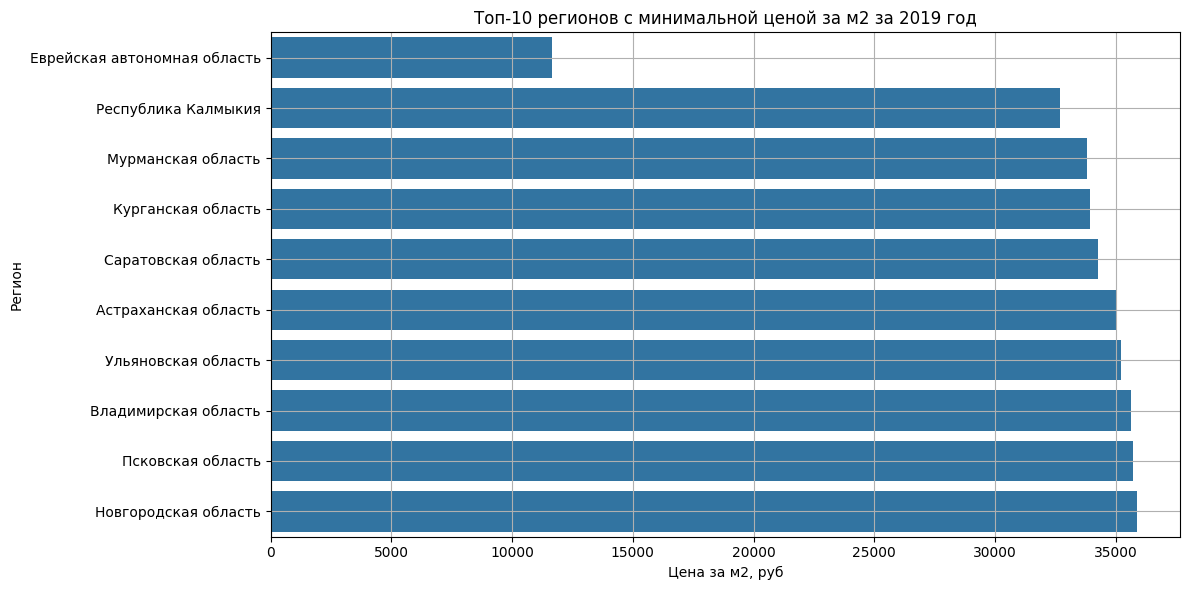

In [486]:
# визуализация отчета с топ-10 регионами с минимальной ценой за 2019 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_19_min.sort_values('price_m2', ascending=True).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с минимальной ценой за м2 за 2019 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

In [487]:
realty_2020 = realty.query("year == 2020")

In [488]:
realty_20 = realty_2020.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_20.sort_values('price_m2', ascending=False).reset_index().head(10)
# топ-10 регионов с максимальной ценой за 2020 год

,reg_name,price_m2
0,Москва,221013.907526
1,Санкт-Петербург,136202.085794
2,Сахалинская область,135416.666667
3,Московская область,100032.328164
4,Приморский край,92941.724943
5,Ленинградская область,87517.789240
6,Республика Крым,85093.625675
7,Амурская область,80605.518087
8,Ямало-Ненецкий автономный округ,77752.156337
9,Архангельская область,72389.847287


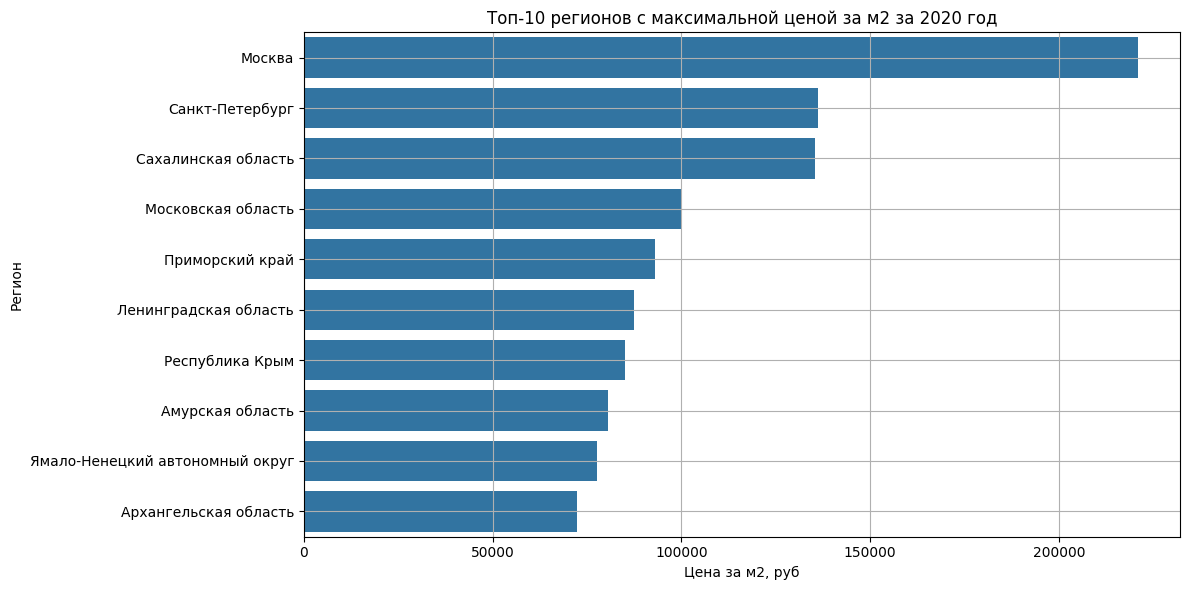

In [489]:
# визуализация отчета с топ-10 регионами с максимальной ценой за 2020 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_20.sort_values('price_m2', ascending=False).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с максимальной ценой за м2 за 2020 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

In [490]:
realty_20_min = realty_2020.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_20_min.sort_values('price_m2', ascending=True).reset_index().head(10)
# топ-10 регионов с минимальной ценой за 2020 год

,reg_name,price_m2
0,Республика Ингушетия,30013.062916
1,Республика Калмыкия,36832.468206
2,Курганская область,36870.037918
3,Челябинская область,38744.993096
4,Республика Марий Эл,39086.462010
5,Саратовская область,39875.073972
6,Псковская область,40111.495385
7,Ивановская область,40923.997751
8,Кемеровская область,41138.242294
9,Республика Северная Осетия — Алания,41525.458357


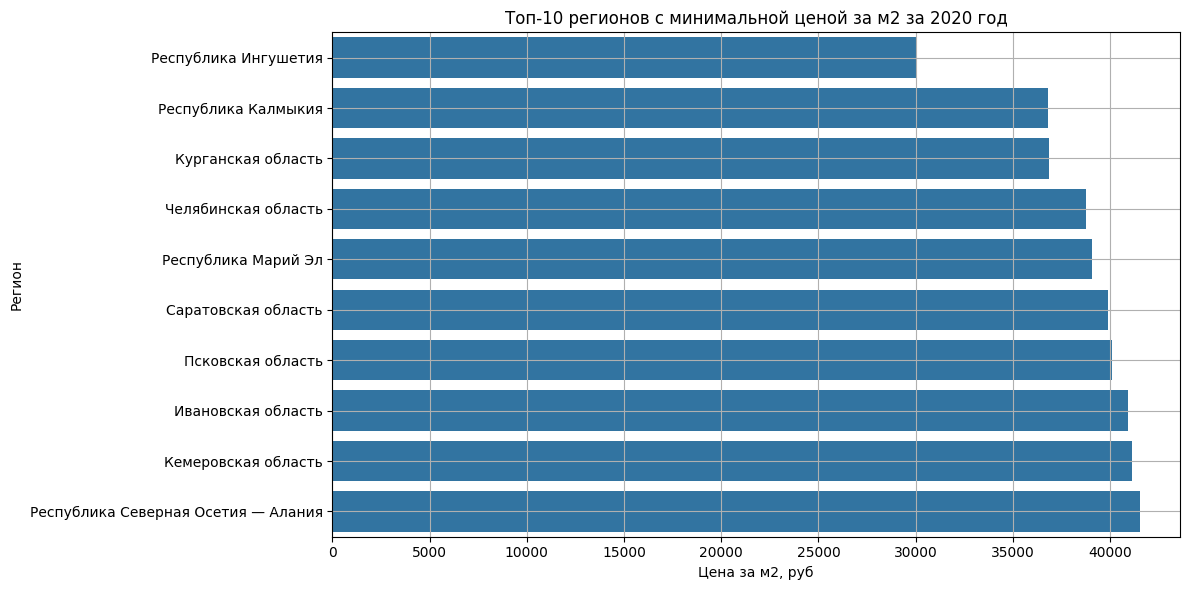

In [491]:
# визуализация отчета с топ-10 регионами с минимальной ценой за 2020 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_20_min.sort_values('price_m2', ascending=True).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с минимальной ценой за м2 за 2020 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

In [492]:
realty_2021 = realty.query("year == 2021")

In [493]:
realty_21 = realty_2021.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_21.sort_values('price_m2', ascending=False).reset_index().head(10)
# топ-10 регионов с максимальной ценой за 2021 год

,reg_name,price_m2
0,Москва,259010.402216
1,Санкт-Петербург,172230.646365
2,Московская область,128511.111683
3,Ленинградская область,115963.915966
4,Ямало-Ненецкий автономный округ,109234.557439
5,Республика Крым,106511.967713
6,Амурская область,104428.982921
7,Республика Тыва,96498.378730
8,Краснодарский край,93127.829104
9,Калининградская область,91426.474913


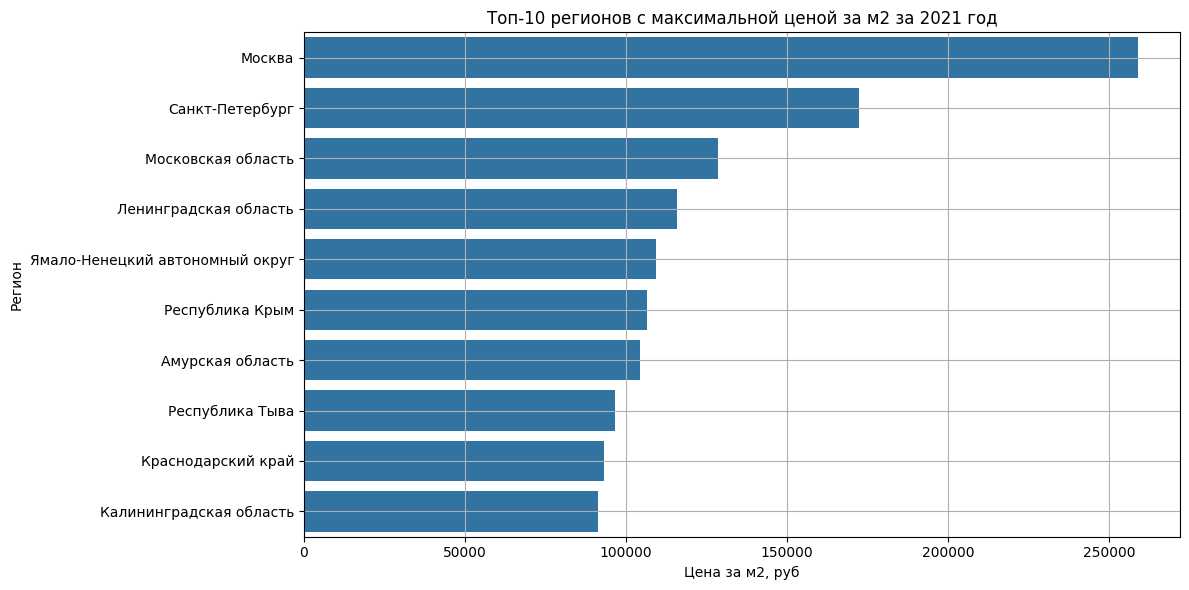

In [494]:
# визуализация отчета с топ-10 регионами с максимальной ценой за 2021 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_21.sort_values('price_m2', ascending=False).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с максимальной ценой за м2 за 2021 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

In [495]:
realty_21_min = realty_2021.pivot_table(
    index = 'reg_name',
    aggfunc = {'price_m2': 'mean'})
realty_21_min.sort_values('price_m2', ascending=True).reset_index().head(10)
# топ-10 регионов с минимальной ценой за 2021 год

,reg_name,price_m2
0,Республика Ингушетия,30382.881043
1,Курганская область,40658.960164
2,Кабардино-Балкарская Республика,43934.411683
3,Челябинская область,44046.844511
4,Республика Марий Эл,44896.138116
5,Саратовская область,47018.673923
6,Кемеровская область,47350.801724
7,Республика Северная Осетия — Алания,47357.425327
8,Новгородская область,47366.836415
9,Республика Калмыкия,48109.801014


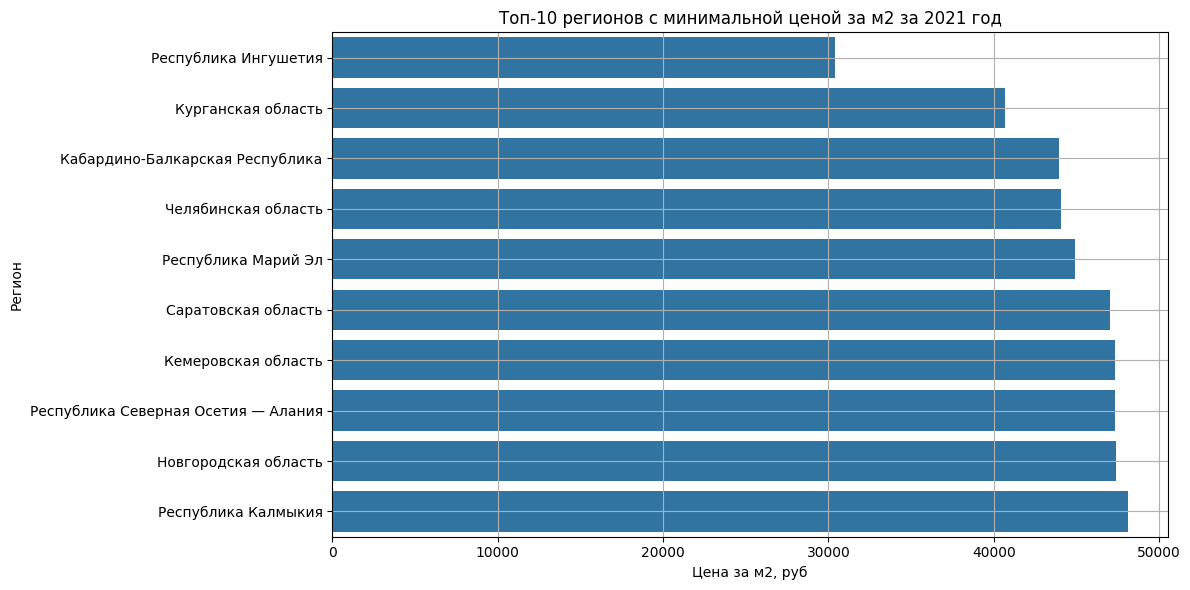

In [496]:
# визуализация отчета с топ-10 регионами с минимальной ценой за 2021 год
plt.figure(figsize=(12, 6))
sns.barplot(data=realty_21_min.sort_values('price_m2', ascending=True).reset_index().head(10),
    x='price_m2',  
    y='reg_name')
plt.title('Топ-10 регионов с минимальной ценой за м2 за 2021 год')
plt.ylabel('Регион')
plt.xlabel('Цена за м2, руб')
plt.grid(True)
plt.tight_layout()
plt.show()

На основе полученных данных, мы можем сделать следующий вывод:

1. **Лидеры по максимальной цене за м2** остаются стабильными - **Москва и Санкт-Петербург** занимают первые два места каждый год, причем их цены значительно выше, чем в других регионах (кроме 2019 года - на втором месте Сахалинская область (в 2019 году в Сахалинской области выдавали субсидии и сертификаты различным категориям граждан (инвалидам, многодетным семьям, сиротам). Это приводило к росту цен: застройщики не успевали удовлетворять спрос, а покупателей было много)).
   
2. **Московская область и Ленинградская область** также стабильно входят в топ-10.

   
3. В топ-10 периодически попадают:
- **Сахалинская область** (в 2019–2020 годах).
- **Ямало-Ненецкий АО** (2019–2021).
- **Республика Крым** (2018–2021).
- **Хабаровский край, Приморский край, Амурская область** (в отдельные годы).
Регионы, не относящиеся к столичным, также попадают в этот список. Это может быть связано с особым спросом, как например, в Республике Крым (курортный регион) и Сахалинской области (ресурсодобывающий регион), высокой стоимостью строительства в удаленных регионах. 

Что касается регионов с минимальной стоимостью за м2, то можно отметить самый дешевый регион в 2018, 2020, 2021 годах - это **республика Ингушетия**.

*Курганская область, Республика Калмыкия, Саратовская область, Республика Марий Эл регулярно входят в топ-10 самых дешёвых регионов по стоимости м2*.

**Причины могут быть следующие**: слабое развитие рынка недвижимости в этих регионах, низкая покупательная способность населения, слабый спрос и отток населения в этих регионах, что приводит к росту количества объектов на продажу и желанию продавцов быстро реализовать недвижимость.

*Цены* в большинстве регионов *растут*:
- Москва: с 177866.13 руб. за м2 (2018) до 259010.40 руб. (2021),
- Санкт-Петербург: со 114492.71 рублей за м2 до 172230.65 руб.,
- Даже в самых "дешёвых регионах" цены выросли (например, Ингушетия с 22905.91 руб. за м2. до 	30382.88 руб.).

**Далее осуществим анализ по типам недвижимости.**

Сравним стоимость м2 по каждому году по типам.

In [497]:
realty

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year,month,period
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058,2018,2,2018-02
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250,2018,2,2018-02
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606,2018,2,2018-02
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526,2018,3,2018-03
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333,2018,3,2018-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000,2021,5,2021-05
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000,2021,5,2021-05
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046,2021,5,2021-05
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000,2021,5,2021-05


In [505]:
realty.loc[realty['object_type'] == 1, 'object_type_name'] = 'Вторичный рынок'
realty.loc[realty['object_type'] == 11, 'object_type_name'] = 'Первичный рынок'

In [506]:
realty

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year,month,period,object_type_name
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058,2018,2,2018-02,Вторичный рынок
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250,2018,2,2018-02,Вторичный рынок
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606,2018,2,2018-02,Вторичный рынок
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526,2018,3,2018-03,Первичный рынок
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333,2018,3,2018-03,Вторичный рынок
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000,2021,5,2021-05,Первичный рынок
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000,2021,5,2021-05,Первичный рынок
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046,2021,5,2021-05,Вторичный рынок
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000,2021,5,2021-05,Первичный рынок


In [528]:
realty_object_type = realty.pivot_table(
    index = ['object_type_name', 'year'],
    aggfunc = {'price_m2': 'mean'})
realty_object_type  = realty_object_type.reset_index()
realty_object_type.columns = ['object_type_name', 'year','mean_price_m2']
realty_object_type
# сравниваем цену за м2 на вторичном и первичном рынке с детализацией по году 

,object_type_name,year,mean_price_m2
0,Вторичный рынок,2018,68454.803881
1,Вторичный рынок,2019,72937.775363
2,Вторичный рынок,2020,80033.744855
3,Вторичный рынок,2021,97937.441477
4,Первичный рынок,2018,79833.654351
5,Первичный рынок,2019,83531.062110
6,Первичный рынок,2020,102432.992255
7,Первичный рынок,2021,127460.983422


Таким образом, **первичный рынок стабильно дороже вторичного**. 
В каждый год средняя цена на первичном рынке выше:

*2018*: 79833.65 руб. против 68454.80 руб. 

*2019*: 83531.06 руб. против 72937.78 руб. 

*2020*: 102432.99 руб. против 80033.74 руб.

*2021*: 127460.98 руб. против 97937.44 руб.

*Вывод: новостройки в среднем дороже «вторички».* Новостройки становятся всё более премиальными относительно вторичного жилья.

**Возможные причины: изменение ипотечных условий (льготные программы), инфляция, пандемийный спрос, рост стоимости стройматериалов и девелоперских проектов.**

Даже в кризисный 2020 год цены продолжили расти на обоих рынках, что говорит об устойчивости спроса на жилье в РФ в этот период.

In [533]:
realty_object_type1 = realty.query("object_type_name == 'Первичный рынок'")
realty_object_type1

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year,month,period,object_type_name
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526,2018,3,2018-03,Первичный рынок
6,2018-03-04,3,2,11,1,25,1,31.7,6.0,4704280.0,Москва,0.309,148400.000000,2018,3,2018-03,Первичный рынок
8,2018-03-05,3106,2,11,4,24,2,64.0,13.0,3390000.0,Самарская область,0.184,52968.750000,2018,3,2018-03,Первичный рынок
10,2018-03-06,81,1,11,9,14,3,76.1,8.8,6909880.0,Московская область,0.133,90800.000000,2018,3,2018-03,Первичный рынок
11,2018-03-06,81,1,11,10,14,1,40.3,11.0,4291950.0,Московская область,0.242,106500.000000,2018,3,2018-03,Первичный рынок
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235936,2021-05-01,3446,2,11,2,3,2,59.0,22.3,7200000.0,Ленинградская область,0.211,122033.898305,2021,5,2021-05,Первичный рынок
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000,2021,5,2021-05,Первичный рынок
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000,2021,5,2021-05,Первичный рынок
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000,2021,5,2021-05,Первичный рынок


In [536]:
realty_object_type_ = realty_object_type1.pivot_table(
    index = 'period',
    aggfunc = {'price_m2': 'mean'})
realty_object_type_  = realty_object_type_.reset_index()
realty_object_type_.columns = ['period','mean_price_m2']
realty_object_type_
# цена за м2 на первичном рынке с детализацией по периоду

,period,mean_price_m2
0,2018-03,84427.225437
1,2018-04,55386.504831
2,2018-05,54105.114175
3,2018-06,63760.356270
4,2018-07,66437.720696
5,2018-08,85331.300138
6,2018-09,79560.209140
7,2018-10,68610.452223
8,2018-11,72407.455946
9,2018-12,94580.546933


In [537]:
realty_object_type2 = realty.query("object_type_name == 'Вторичный рынок'")
realty_object_type2

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year,month,period,object_type_name
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058,2018,2,2018-02,Вторичный рынок
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250,2018,2,2018-02,Вторичный рынок
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606,2018,2,2018-02,Вторичный рынок
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333,2018,3,2018-03,Вторичный рынок
5,2018-03-02,81,1,1,4,5,1,32.0,6.0,3300000.0,Московская область,0.242,103125.000000,2018,3,2018-03,Вторичный рынок
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235935,2021-05-01,81,3,1,4,17,3,82.0,10.6,6400000.0,Московская область,0.127,78048.780488,2021,5,2021-05,Вторичный рынок
5235937,2021-05-01,2661,1,1,2,5,1,31.0,6.0,4900000.0,Санкт-Петербург,0.248,158064.516129,2021,5,2021-05,Вторичный рынок
5235938,2021-05-01,3,2,1,12,24,1,41.0,9.0,12850000.0,Москва,0.309,313414.634146,2021,5,2021-05,Вторичный рынок
5235939,2021-05-01,2900,3,1,4,5,4,178.0,20.0,9000000.0,Ставропольский край,0.133,50561.797753,2021,5,2021-05,Вторичный рынок


In [538]:
realty_object_type_2 = realty_object_type2.pivot_table(
    index = 'period',
    aggfunc = {'price_m2': 'mean'})
realty_object_type_2  = realty_object_type_2.reset_index()
realty_object_type_2.columns = ['period','mean_price_m2']
realty_object_type_2
# цена за м2 на вторичном рынке с детализацией по периоду

,period,mean_price_m2
0,2018-02,86343.836638
1,2018-03,74513.403192
2,2018-04,86073.026628
3,2018-05,75791.874856
4,2018-06,70692.679570
5,2018-07,61417.661846
6,2018-08,69595.435755
7,2018-09,71521.197758
8,2018-10,67759.732112
9,2018-11,70899.756997


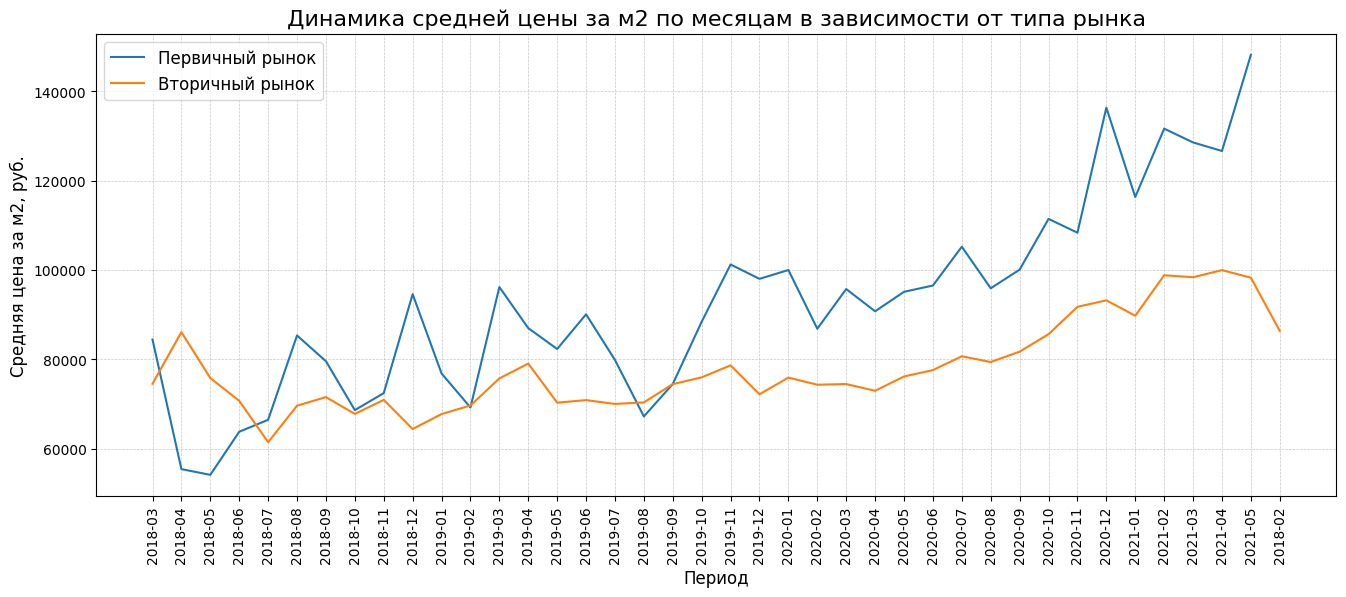

In [556]:
plt.figure(figsize=(16, 6))

sns.lineplot(data = realty_object_type_, x='period', y='mean_price_m2', label='Первичный рынок')
(sns.lineplot(data = realty_object_type_2,x='period', y='mean_price_m2', label='Вторичный рынок'))
plt.title('Динамика средней цены за м2 по месяцам в зависимости от типа рынка', fontsize=16)
plt.xlabel('Период', fontsize=12)
plt.ylabel('Средняя цена за м2, руб.', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.show()
# визуализация

Линия первичного рынка находится выше линии вторичного на протяжении почти всего периода (кроме первой половины 2018 года). 

2020 год — заметный рост на обоих рынках, особенно на первичном.
2021 год — продолжение роста, причём первичный рынок показывает более крутой подъём.

*Вторичный рынок показывает более плавную динамику*.
*Первичный рынок более волатилен* - заметны более резкие подъёмы и спады.

Несмотря на пандемию, рынок не показал существенного падения, наоборот - рост продолжился.

Это говорит об устойчивости спроса на жильё как на некий "защитный актив".

In [560]:
realty

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year,month,period,object_type_name
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058,2018,2,2018-02,Вторичный рынок
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250,2018,2,2018-02,Вторичный рынок
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606,2018,2,2018-02,Вторичный рынок
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526,2018,3,2018-03,Первичный рынок
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333,2018,3,2018-03,Вторичный рынок
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000,2021,5,2021-05,Первичный рынок
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000,2021,5,2021-05,Первичный рынок
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046,2021,5,2021-05,Вторичный рынок
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000,2021,5,2021-05,Первичный рынок


In [ ]:
realty_object_type_2 = realty_object_type2.pivot_table(
    index = 'period',
    aggfunc = {'price_m2': 'mean'})
realty_object_type_2  = realty_object_type_2.reset_index()
realty_object_type_2.columns = ['period','mean_price_m2']
realty_object_type_2
# цена за м2 на вторичном рынке с детализацией по периоду

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_rev_report_ffp_flag,
    x='period',  
    y='revenue_amount_per',
    hue='ffp_flag', # детализация по наличию у клиентов карты лояльности 
    palette=['deeppink', 'lightpink'])

plt.title('Выручка по периодам с детализацией по картам лояльности')
plt.ylabel('Доля выручки, %')
plt.xlabel('Период')
plt.grid(True)
plt.tight_layout()
plt.show()

In [573]:
realty.loc[realty['building_type'] == 0, 'building_type_name'] = 'Другое'
realty.loc[realty['building_type'] == 1, 'building_type_name'] = 'Панельный'
realty.loc[realty['building_type'] == 2, 'building_type_name'] = 'Кирпично-монолитный'
realty.loc[realty['building_type'] == 3, 'building_type_name'] = 'Кирпичный'
realty.loc[realty['building_type'] == 4, 'building_type_name'] = 'Блочный'
realty.loc[realty['building_type'] == 5, 'building_type_name'] = 'Деревянный'

In [577]:
realty

,date,region,building_type,object_type,level,levels,rooms,area,kitchen_area,price,reg_name,share_kitchen_area_typical,price_m2,year,month,period,object_type_name,building_type_name
0,2018-02-19,2661,1,1,8,10,3,82.6,10.8,6050000.0,Санкт-Петербург,0.127,73244.552058,2018,2,2018-02,Вторичный рынок,Панельный
1,2018-02-27,81,3,1,5,24,2,69.1,12.0,8650000.0,Московская область,0.150,125180.897250,2018,2,2018-02,Вторичный рынок,Кирпичный
2,2018-02-28,2871,1,1,5,9,3,66.0,10.0,4000000.0,Нижегородская область,0.127,60606.060606,2018,2,2018-02,Вторичный рынок,Панельный
3,2018-03-01,2843,4,11,12,16,2,38.0,5.0,1850000.0,Краснодарский край,0.195,48684.210526,2018,3,2018-03,Первичный рынок,Блочный
4,2018-03-01,81,3,1,13,14,2,60.0,10.0,5450000.0,Московская область,0.150,90833.333333,2018,3,2018-03,Вторичный рынок,Кирпичный
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5235940,2021-05-01,3,1,11,8,17,4,93.2,13.8,19739760.0,Москва,0.105,211800.000000,2021,5,2021-05,Первичный рынок,Панельный
5235941,2021-05-01,3,2,11,17,32,2,45.9,6.6,12503160.0,Москва,0.225,272400.000000,2021,5,2021-05,Первичный рынок,Кирпично-монолитный
5235942,2021-05-01,2871,2,1,4,17,3,86.5,11.8,8800000.0,Нижегородская область,0.157,101734.104046,2021,5,2021-05,Вторичный рынок,Кирпично-монолитный
5235943,2021-05-01,3,1,11,8,33,2,52.1,18.9,11831910.0,Москва,0.173,227100.000000,2021,5,2021-05,Первичный рынок,Панельный


In [578]:
realty1t = realty.query("building_type_name == 'Другое'")
realty2t = realty.query("building_type_name == 'Панельный'")
realty3t = realty.query("building_type_name == 'Кирпично-монолитный'")
realty4t = realty.query("building_type_name == 'Кирпичный'")
realty5t = realty.query("building_type_name == 'Блочный'")
realty6t = realty.query("building_type_name == 'Деревянный'")

In [582]:
realty1tt = realty1t.pivot_table(
    index = ['object_type_name', 'period'],
    aggfunc = {'price_m2': 'mean'})
realty1tt
# цена за м2 на первичном и вторичном рынке с детализацией по периоду по типу здания - другое

price_m2
object_type_name period                
Вторичный рынок  2018-09  108385.852953
                 2018-10   71959.529383
                 2018-11   65207.243663
                 2018-12   67166.898398
                 2019-01   68447.500460
...                                 ...
Первичный рынок  2021-01  101340.214946
                 2021-02  103951.839249
                 2021-03  102687.863522
                 2021-04  102592.243552
                 2021-05  108766.655041

[66 rows x 1 columns]

In [584]:
realty2tt = realty2t.pivot_table(
    index = ['object_type_name', 'period'],
    aggfunc = {'price_m2': 'mean'})
realty2tt
# цена за м2 на первичном и вторичном рынке с детализацией по периоду по типу здания - панельный

price_m2
object_type_name period                
Вторичный рынок  2018-02   66925.306332
                 2018-03   83810.293949
                 2018-04   98470.214631
                 2018-05   64498.101758
                 2018-06   86427.407749
...                                 ...
Первичный рынок  2021-01  105240.306912
                 2021-02  110202.206537
                 2021-03  108991.549159
                 2021-04  107437.144263
                 2021-05  128108.329136

[77 rows x 1 columns]

In [585]:
realty3tt = realty3t.pivot_table(
    index = ['object_type_name', 'period'],
    aggfunc = {'price_m2': 'mean'})
realty3tt
# цена за м2 на первичном и вторичном рынке с детализацией по периоду по типу здания - кирпично-монолитный

price_m2
object_type_name period                
Вторичный рынок  2018-04  139168.714169
                 2018-06   99722.222222
                 2018-07   96615.747420
                 2018-08   93822.966671
                 2018-09   92616.675594
...                                 ...
Первичный рынок  2021-01  139456.706983
                 2021-02  159769.489211
                 2021-03  158791.969143
                 2021-04  159751.381429
                 2021-05  186495.095075

[74 rows x 1 columns]

In [586]:
realty4tt = realty4t.pivot_table(
    index = ['object_type_name', 'period'],
    aggfunc = {'price_m2': 'mean'})
realty4tt
# цена за м2 на первичном и вторичном рынке с детализацией по периоду по типу здания - кирпичный

price_m2
object_type_name period                
Вторичный рынок  2018-02  125180.897250
                 2018-03   61497.756132
                 2018-04   68399.925974
                 2018-05   85830.784276
                 2018-06   60738.403264
...                                 ...
Первичный рынок  2021-01   84292.745093
                 2021-02   99224.524381
                 2021-03   86843.907360
                 2021-04   87076.860924
                 2021-05   84069.757862

[78 rows x 1 columns]

In [587]:
realty5tt = realty5t.pivot_table(
    index = ['object_type_name', 'period'],
    aggfunc = {'price_m2': 'mean'})
realty5tt
# цена за м2 на первичном и вторичном рынке с детализацией по периоду по типу здания - блочный

price_m2
object_type_name period               
Вторичный рынок  2018-04  47844.202899
                 2018-06  70103.092784
                 2018-07  63192.543095
                 2018-08  65003.267974
                 2018-09  63451.421846
...                                ...
Первичный рынок  2021-01  69530.671727
                 2021-02  64728.615458
                 2021-03  70172.867031
                 2021-04  75038.884764
                 2021-05  89550.894227

[72 rows x 1 columns]

In [588]:
realty6tt = realty6t.pivot_table(
    index = ['object_type_name', 'period'],
    aggfunc = {'price_m2': 'mean'})
realty6tt
# цена за м2 на первичном и вторичном рынке с детализацией по периоду по типу здания - деревянный

price_m2
object_type_name period                
Вторичный рынок  2018-06   21698.113208
                 2018-09   67327.172522
                 2018-10   79843.559030
                 2018-11   28292.254539
                 2018-12   28842.717004
...                                 ...
Первичный рынок  2020-12  108169.130254
                 2021-01   88734.958750
                 2021-02   80345.901486
                 2021-03   61268.801683
                 2021-04   88955.851153

[66 rows x 1 columns]

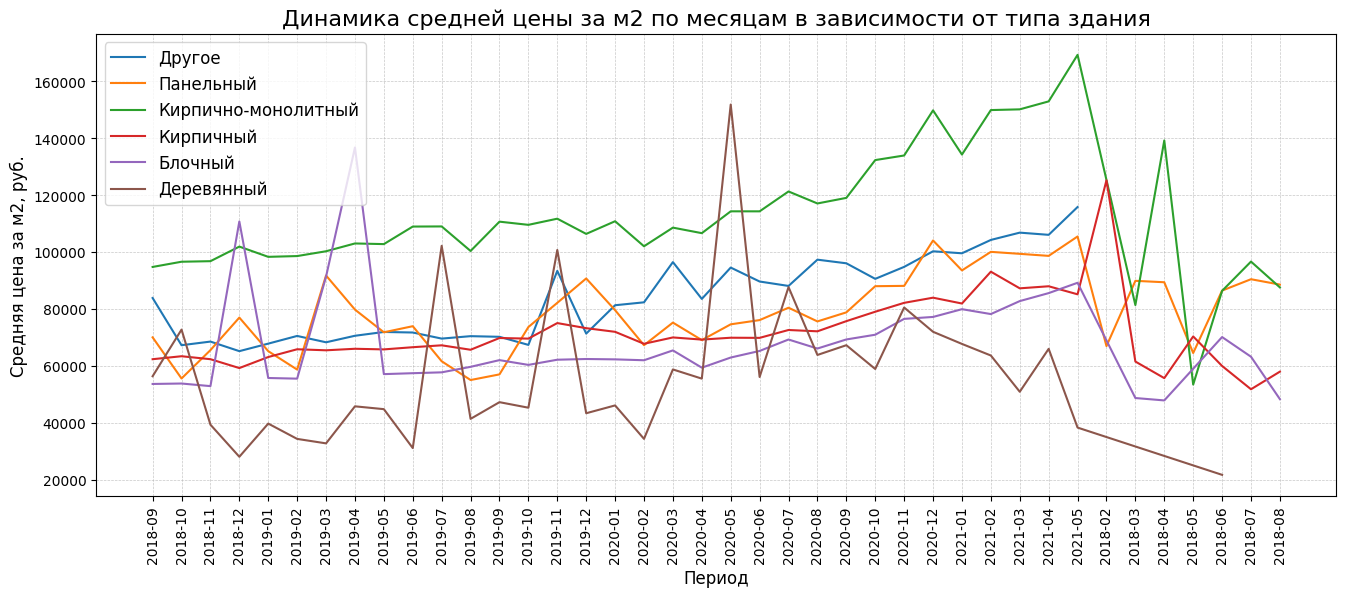

In [595]:
plt.figure(figsize=(16, 6))

sns.lineplot(data = realty1tt, x='period', y='price_m2', label='Другое', errorbar=None)
(sns.lineplot(data = realty2tt,x='period', y='price_m2', label='Панельный', errorbar=None))
(sns.lineplot(data = realty3tt,x='period', y='price_m2', label='Кирпично-монолитный', errorbar=None))
(sns.lineplot(data = realty4tt,x='period', y='price_m2', label='Кирпичный', errorbar=None))
(sns.lineplot(data = realty5tt,x='period', y='price_m2', label='Блочный', errorbar=None))
(sns.lineplot(data = realty6tt,x='period', y='price_m2', label='Деревянный', errorbar=None))
plt.title('Динамика средней цены за м2 по месяцам в зависимости от типа здания', fontsize=16)
plt.xlabel('Период', fontsize=12)
plt.ylabel('Средняя цена за м2, руб.', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.show()
# визуализация

In [ ]:
plt.figure(figsize=(16, 6))

sns.lineplot(data = realty_object_type_, x='period', y='mean_price_m2', label='Первичный рынок')
(sns.lineplot(data = realty_object_type_2,x='period', y='mean_price_m2', label='Вторичный рынок'))
plt.title('Динамика средней цены за м2 по месяцам в зависимости от типа рынка', fontsize=16)
plt.xlabel('Период', fontsize=12)
plt.ylabel('Средняя цена за м2, руб.', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.show()
# визуализация